UCL Final 2018 — Liverpool vs Tottenham
Match Analysis Report
[abdelrhman madian]

In [3]:
# Install football data libraries
!pip install mplsoccer statsbombpy -q

# Import everything you need
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from statsbombpy import sb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00


In [4]:
competitions = sb.competitions()
print(competitions[['competition_id', 'season_id', 'competition_name', 'season_name']])

    competition_id  season_id        competition_name season_name
0                9        281           1. Bundesliga   2023/2024
1                9         27           1. Bundesliga   2015/2016
2             1267        107  African Cup of Nations        2023
3               16          4        Champions League   2018/2019
4               16          1        Champions League   2017/2018
..             ...        ...                     ...         ...
70              35         75      UEFA Europa League   1988/1989
71              53        315       UEFA Women's Euro        2025
72              53        106       UEFA Women's Euro        2022
73              72        107       Women's World Cup        2023
74              72         30       Women's World Cup        2019

[75 rows x 4 columns]


In [5]:
matches3 = sb.matches(competition_id=16, season_id=4)
print(matches3[['match_id', 'home_team', 'away_team', 'match_date']])


   match_id          home_team  away_team  match_date
0     22912  Tottenham Hotspur  Liverpool  2019-06-01


In [6]:
match_id3 = matches3.iloc[0]['match_id']
home = matches3.iloc[0]['home_team']
away = matches3.iloc[0]['away_team']
print(f"Match: {home} vs {away}")

events3 = sb.events(match_id=match_id3)
print(events3['type'].value_counts())

Match: Tottenham Hotspur vs Liverpool
type
Pass                 890
Ball Receipt*        846
Carry                669
Pressure             314
Ball Recovery        100
Duel                  56
Clearance             51
Goal Keeper           38
Shot                  30
Block                 25
Miscontrol            22
Dispossessed          19
Dribble               15
Foul Committed        15
Interception          15
Foul Won              12
Dribbled Past         10
50/50                  6
Substitution           6
Shield                 5
Half Start             4
Tactical Shift         4
Injury Stoppage        4
Half End               4
Starting XI            2
Referee Ball-Drop      2
Offside                1
Name: count, dtype: int64


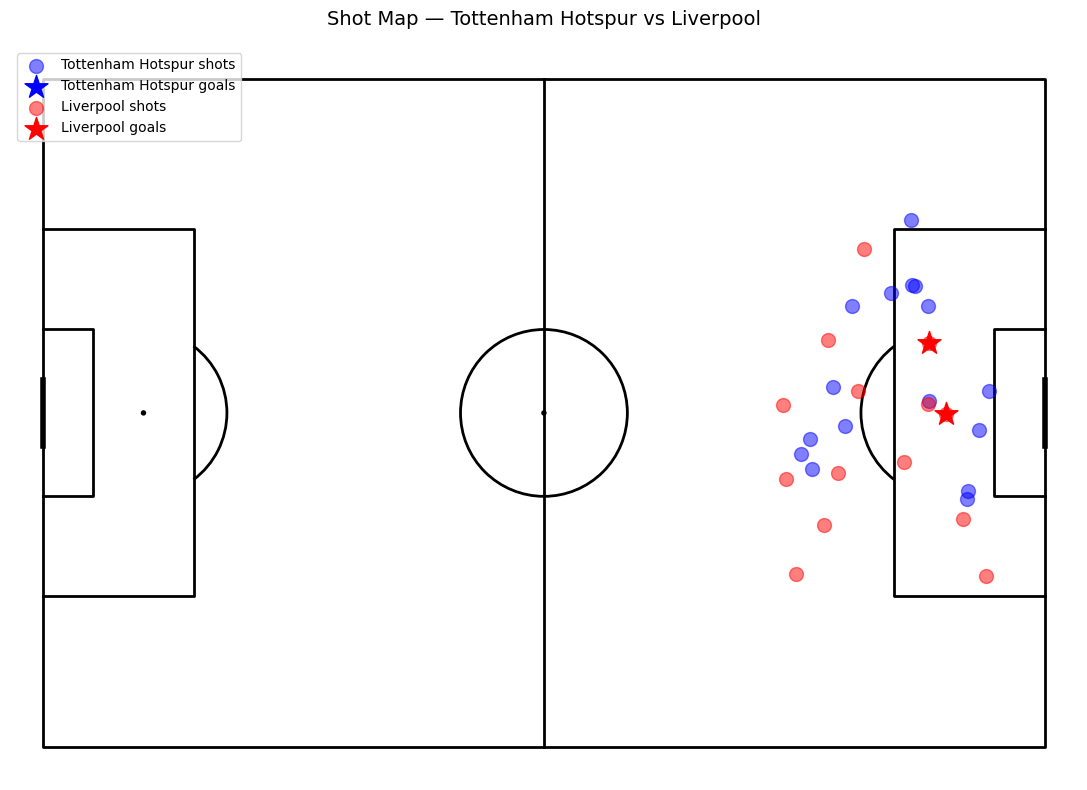

In [7]:
shots = events3[events3['type'] == 'Shot'].copy()
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

home_shots = shots[shots['team'] == home]
away_shots = shots[shots['team'] == away]

home_goals = home_shots[home_shots['shot_outcome'] == 'Goal']
away_goals = away_shots[away_shots['shot_outcome'] == 'Goal']

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(home_shots['x'], home_shots['y'], ax=ax,
              s=100, color='blue', alpha=0.5, label=f'{home} shots')
pitch.scatter(home_goals['x'], home_goals['y'], ax=ax,
              s=300, color='blue', marker='*', label=f'{home} goals')

pitch.scatter(away_shots['x'], away_shots['y'], ax=ax,
              s=100, color='red', alpha=0.5, label=f'{away} shots')
pitch.scatter(away_goals['x'], away_goals['y'], ax=ax,
              s=300, color='red', marker='*', label=f'{away} goals')

ax.set_title(f'Shot Map — {home} vs {away}', fontsize=14, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

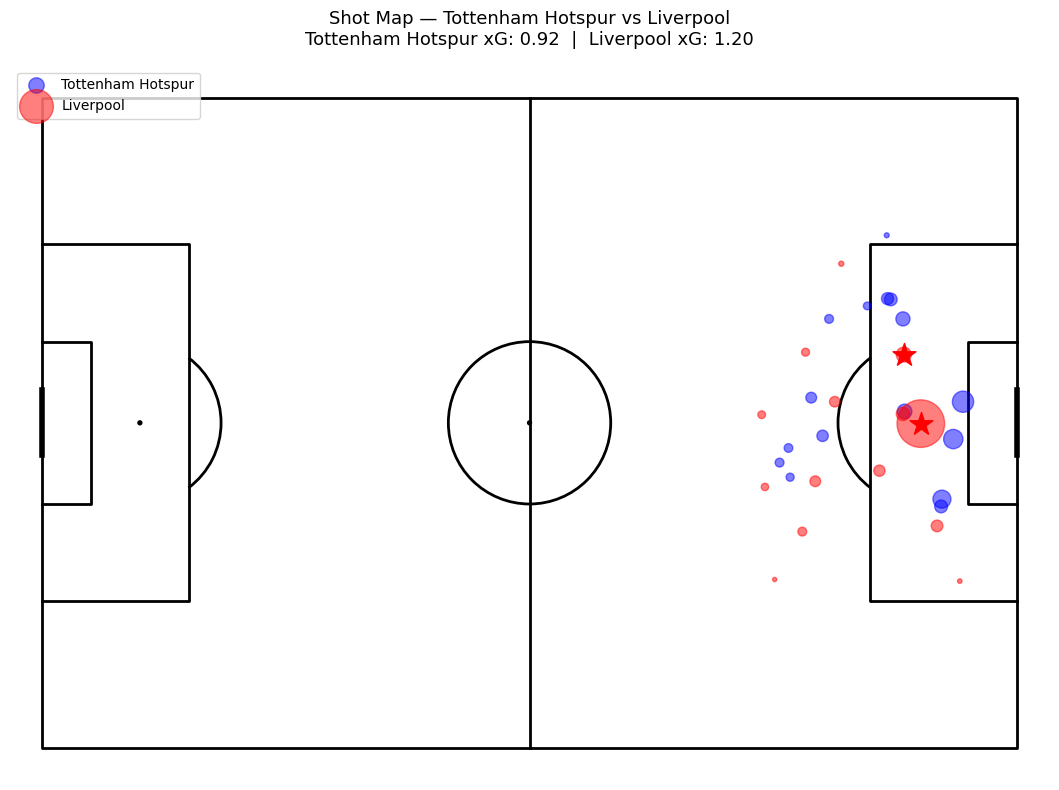

In [8]:
shots = events3[events3['type'] == 'Shot'].copy()
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

home_shots = shots[shots['team'] == home]
away_shots = shots[shots['team'] == away]

home_goals = home_shots[home_shots['shot_outcome'] == 'Goal']
away_goals = away_shots[away_shots['shot_outcome'] == 'Goal']

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(home_shots['x'], home_shots['y'], ax=ax,
              s=home_shots['shot_statsbomb_xg'] * 1500,
              color='blue', alpha=0.5, label=f'{home}')
pitch.scatter(home_goals['x'], home_goals['y'], ax=ax,
              s=300, color='blue', marker='*')

pitch.scatter(away_shots['x'], away_shots['y'], ax=ax,
              s=away_shots['shot_statsbomb_xg'] * 1500,
              color='red', alpha=0.5, label=f'{away}')
pitch.scatter(away_goals['x'], away_goals['y'], ax=ax,
              s=300, color='red', marker='*')

# xG totals
home_xg = home_shots['shot_statsbomb_xg'].sum()
away_xg = away_shots['shot_statsbomb_xg'].sum()

ax.set_title(f'Shot Map — {home} vs {away}\n'
             f'{home} xG: {home_xg:.2f}  |  {away} xG: {away_xg:.2f}',
             fontsize=13, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
print(f"\n{home} shots:")
print(home_shots[['player', 'minute', 'shot_statsbomb_xg', 'shot_outcome']].sort_values('shot_statsbomb_xg', ascending=False).to_string())

print(f"\n{away} shots:")
print(away_shots[['player', 'minute', 'shot_statsbomb_xg', 'shot_outcome']].sort_values('shot_statsbomb_xg', ascending=False).to_string())


Tottenham Hotspur shots:
                              player  minute  shot_statsbomb_xg shot_outcome
2814                   Bamidele Alli      78           0.156363        Off T
2820  Lucas Rodrigues Moura da Silva      84           0.129618      Blocked
2808                   Bamidele Alli      53           0.112690      Blocked
2816  Lucas Rodrigues Moura da Silva      79           0.073947        Saved
2813                   Bamidele Alli      72           0.069482        Saved
2810                  Jan Vertonghen      57           0.057149        Off T
2824                   Heung-Min Son      92           0.056256        Saved
2825                      Harry Kane      92           0.050692        Saved
2805     Christian Dannemann Eriksen      45           0.045139        Off T
2817                   Heung-Min Son      80           0.040406        Saved
2815                   Heung-Min Son      79           0.027246        Saved
2823                      Danny Rose      91      

In [10]:
passes = events3[events3['type'] == 'Pass'].copy()
passes['x'] = passes['location'].apply(lambda loc: loc[0])
passes['y'] = passes['location'].apply(lambda loc: loc[1])
passes['end_x'] = passes['pass_end_location'].apply(lambda loc: loc[0])
passes['end_y'] = passes['pass_end_location'].apply(lambda loc: loc[1])

liverpool_passes = passes[passes['team'] == home]
spurs_passes = passes[passes['team'] == away]

print(f"{home} total passes: {len(liverpool_passes)}")
print(f"{away} total passes: {len(spurs_passes)}")
print(f"\n{home} pass accuracy: {(liverpool_passes['pass_outcome'].isna().sum() / len(liverpool_passes) * 100):.1f}%")
print(f"{away} pass accuracy: {(spurs_passes['pass_outcome'].isna().sum() / len(spurs_passes))* 100:.1f}%")

Tottenham Hotspur total passes: 564
Liverpool total passes: 326

Tottenham Hotspur pass accuracy: 79.3%
Liverpool pass accuracy: 62.0%


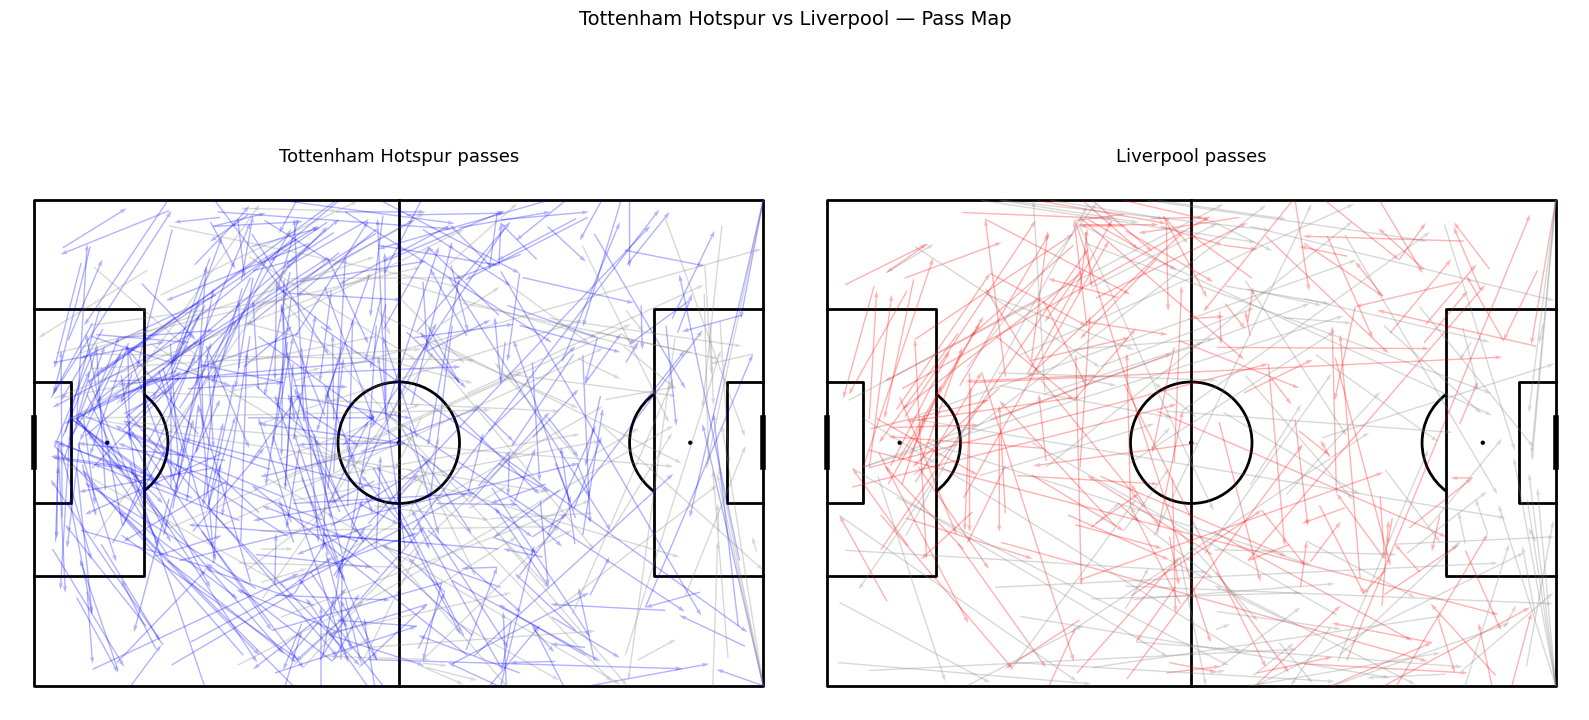

In [11]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axes = pitch.draw(ncols=2, figsize=(16, 8))

for ax, team_passes, team_name, color in [
    (axes[0], liverpool_passes, home, 'blue'),
    (axes[1], spurs_passes, away, 'red')
]:
    complete = team_passes[team_passes['pass_outcome'].isna()]
    incomplete = team_passes[team_passes['pass_outcome'].notna()]

    pitch.arrows(complete['x'], complete['y'],
                 complete['end_x'], complete['end_y'],
                 ax=ax, color=color, alpha=0.3, width=1)

    pitch.arrows(incomplete['x'], incomplete['y'],
                 incomplete['end_x'], incomplete['end_y'],
                 ax=ax, color='gray', alpha=0.3, width=1)

    ax.set_title(f'{team_name} passes', fontsize=13, pad=10)

plt.suptitle(f'{home} vs {away} — Pass Map', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Filter all pressure events
pressure = events3[events3['type'] == 'Pressure'].copy()
pressure['x'] = pressure['location'].apply(lambda loc: loc[0])
pressure['y'] = pressure['location'].apply(lambda loc: loc[1])

liverpool_press = pressure[pressure['team'] == home]
spurs_press = pressure[pressure['team'] == away]

print(f"{home} total pressures: {len(liverpool_press)}")
print(f"{away} total pressures: {len(spurs_press)}")

Tottenham Hotspur total pressures: 64
Liverpool total pressures: 250


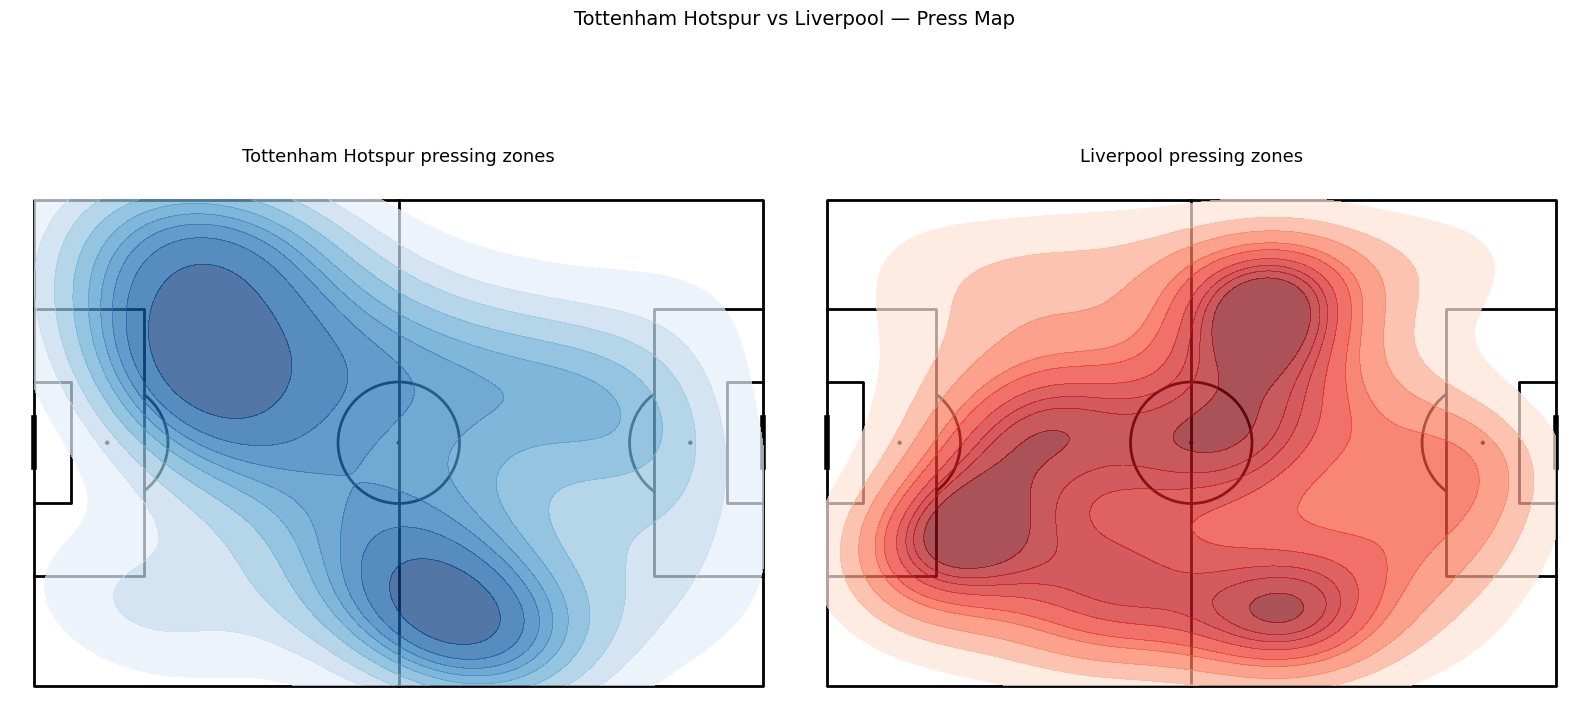

In [13]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axes = pitch.draw(ncols=2, figsize=(16, 8))

for ax, press, team_name, color in [
    (axes[0], liverpool_press, home, 'blue'),
    (axes[1], spurs_press, away, 'red')
]:
    pitch.kdeplot(press['x'], press['y'], ax=ax,
                  fill=True, cmap='Blues' if color == 'blue' else 'Reds',
                  levels=10, alpha=0.7)
    ax.set_title(f'{team_name} pressing zones', fontsize=13, pad=10)

plt.suptitle(f'{home} vs {away} — Press Map', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Liverpool started the match playing high press and long passes more direct to the goal that made salah score the first on the 2nd min on the other hand spurs players became unstable and more behind also as they were playing short passes and low press due to Liverpool's high press on there half that made spurs had the most passes and more accurate but less dangerous and the biggest mistake happened is  when  Pochettino replaced Alli on the 78th min and he was the highest xG player with 0.156363 and the team had more xG than Liverpool this takes Origi to score  the second goal on the 86 min to secure the win for Liverpool

In [14]:
matches3 = sb.matches(competition_id=16, season_id=4)
match_id3 = matches3.iloc[0]['match_id']
home = matches3.iloc[0]['home_team']
away = matches3.iloc[0]['away_team']
events3 = sb.events(match_id=match_id3)

print(f"Loaded: {home} vs {away}")
print(f"Total events: {len(events3)}")

Loaded: Tottenham Hotspur vs Liverpool
Total events: 3165


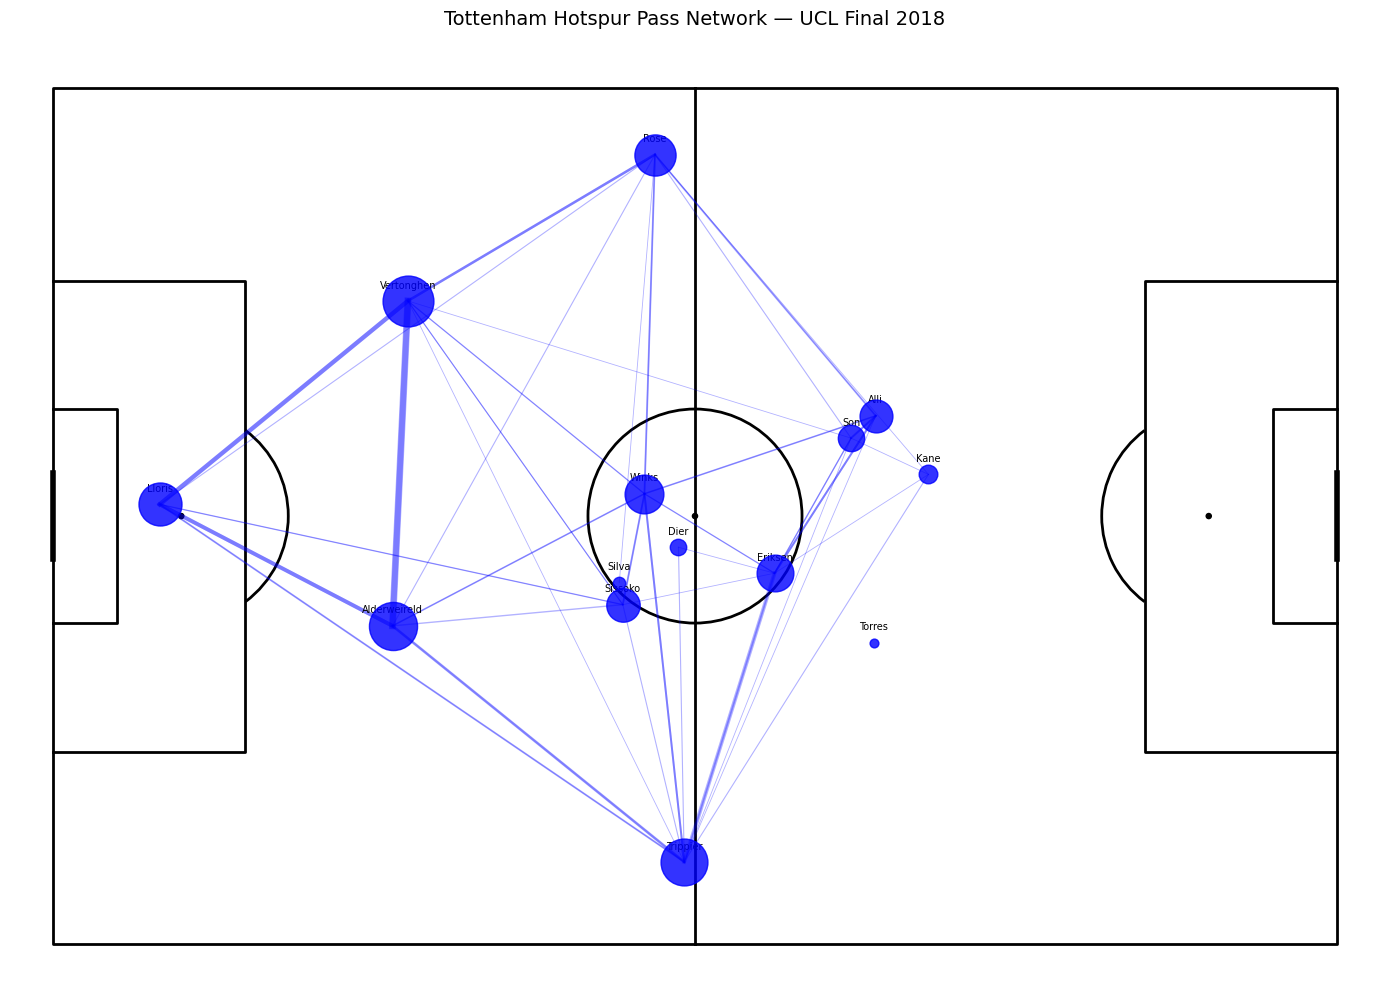

In [15]:
import numpy as np

# Get passes for each team
passes = events3[events3['type'] == 'Pass'].copy()
passes = passes[passes['pass_outcome'].isna()]  # completed passes only

# Focus on Liverpool
team_passes = passes[passes['team'] == home].copy()

# Get player average positions
team_passes['x'] = team_passes['location'].apply(lambda loc: loc[0])
team_passes['y'] = team_passes['location'].apply(lambda loc: loc[1])

player_positions = team_passes.groupby('player').agg(
    x=('x', 'mean'),
    y=('y', 'mean'),
    count=('x', 'count')
).reset_index()

# Count passes between players
team_passes['recipient'] = team_passes['pass_recipient']
combos = team_passes.groupby(['player', 'recipient']).size().reset_index(name='pass_count')
combos = combos[combos['pass_count'] >= 3]  # only show connections with 3+ passes

# Draw the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(14, 10))

# Draw connections between players
for _, row in combos.iterrows():
    if row['player'] in player_positions['player'].values and \
       row['recipient'] in player_positions['player'].values:
        p1 = player_positions[player_positions['player'] == row['player']].iloc[0]
        p2 = player_positions[player_positions['player'] == row['recipient']].iloc[0]
        ax.plot([p1['x'], p2['x']], [p1['y'], p2['y']],
                color='blue', alpha=0.3, linewidth=row['pass_count'] * 0.2)

# Draw player nodes
for _, player in player_positions.iterrows():
    ax.scatter(player['x'], player['y'],
               s=player['count'] * 20, color='blue', alpha=0.8, zorder=5)
    ax.annotate(player['player'].split()[-1],
                (player['x'], player['y']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_title(f'{home} Pass Network — UCL Final 2018', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

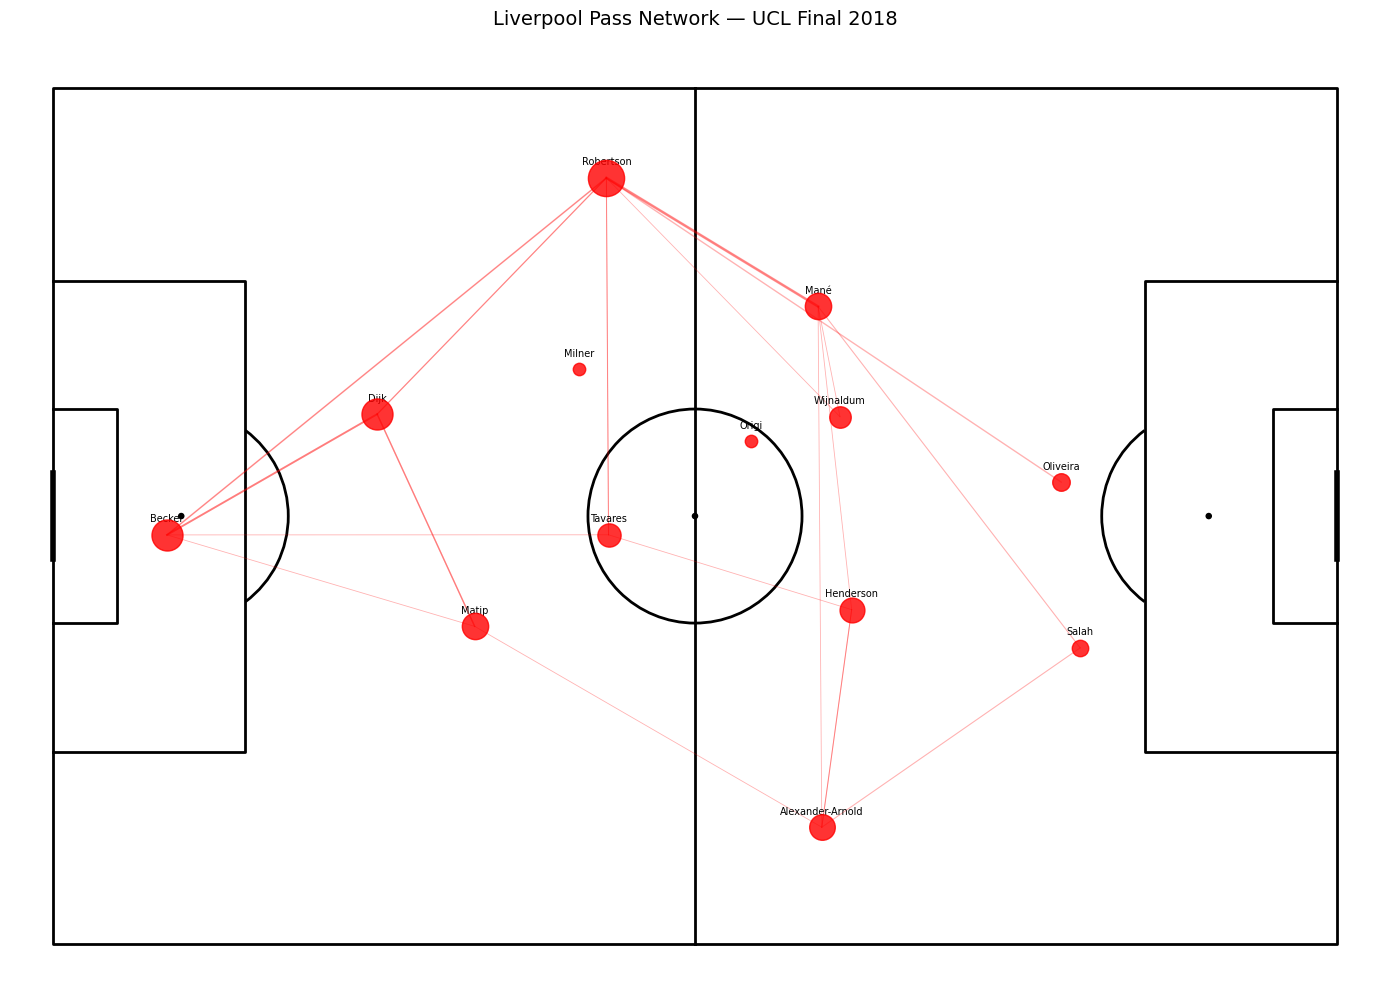

In [16]:
team_passes = passes[passes['team'] == away].copy()
team_passes['x'] = team_passes['location'].apply(lambda loc: loc[0])
team_passes['y'] = team_passes['location'].apply(lambda loc: loc[1])

player_positions = team_passes.groupby('player').agg(
    x=('x', 'mean'),
    y=('y', 'mean'),
    count=('x', 'count')
).reset_index()

combos = team_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')
combos = combos[combos['pass_count'] >= 3]

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(14, 10))

for _, row in combos.iterrows():
    if row['player'] in player_positions['player'].values and \
       row['pass_recipient'] in player_positions['player'].values:
        p1 = player_positions[player_positions['player'] == row['player']].iloc[0]
        p2 = player_positions[player_positions['player'] == row['pass_recipient']].iloc[0]
        ax.plot([p1['x'], p2['x']], [p1['y'], p2['y']],
                color='red', alpha=0.3, linewidth=row['pass_count'] * 0.2)

for _, player in player_positions.iterrows():
    ax.scatter(player['x'], player['y'],
               s=player['count'] * 20, color='red', alpha=0.8, zorder=5)
    ax.annotate(player['player'].split()[-1],
                (player['x'], player['y']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_title(f'{away} Pass Network — UCL Final 2018', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


Spurs were forced to build from the back due to Liverpool's high press, Alderweireld and Vertonghen had the biggest circles which means they had the most passes and they were forming a triangle with Lloris to get out of the pressure but they couldn't find a way forward so they moved the ball wide to Rose and Trippier as the main outlets to escape Liverpool's press.
On the other hand Robertson was the key player in Liverpool's pass network playing as a left midfielder not a left back which is typical in Klopp's system, his strongest connection was with Mané as Liverpool's main attacking route was direct long passes down the left channel into Mané's run. Salah and Firmino had small circles meaning they didn't touch the ball much but that was the plan — they didn't need to be involved in buildup, they just needed to be in the right position at the right moment and Salah proved that by scoring on the 2nd minute.